# Correlated-Case ($\gamma$) Power Spectrum Correction

Spun off from `DM_benchmark_nico_pypower_1_.ipynb`: **only the correlated case**
(section 3.3 of the derivation notes) and the Setup section.

**Setting.** The corrective potential is $\phi_\mathbf{k} = (\gamma_k/k^2)\Delta_\mathbf{k}$ with
$\gamma_k\in\mathbb{R}$ a real, per-$k$-bin scalar. This is the case most likely to improve
$r(k)$ (cross-correlation coefficient) in addition to $P(k)$, since $\phi$ is built directly
from the density field itself.

Fourier convention (fixed, periodic box):
$$
\Delta_\mathbf{k}=\frac{1}{V}\int_V\Delta(\mathbf{x})e^{-i\mathbf{k}\cdot\mathbf{x}}d^3x,\quad
\Delta(\mathbf{x})=\sum_\mathbf{k}\Delta_\mathbf{k}e^{i\mathbf{k}\cdot\mathbf{x}},\quad
\langle\Delta_\mathbf{k}\Delta_{\mathbf{k}'}^*\rangle=\delta_D(\mathbf{k},\mathbf{k}')\frac{P(k)}{V}.
$$

---

## Equation audit (done before writing this notebook)

**Polynomial (no bispectrum, eq. 104 of the notes):**
$$V\langle|\Delta'_\mathbf{k}|^2\rangle_\Delta = P(k)(1+\gamma_k)^2 - P(k) + P(k) + \gamma_k^2P(k)+2\gamma_kP(k)$$
$$\Rightarrow\quad \gamma_k=-1\pm\sqrt{P_\text{target}(k)/P(k)}$$
`get_roots_gamma` solves $P\gamma^2+2P\gamma+(P-P_\text{target})=0$ via `np.roots`. **No issue.**

**Bispectrum term (eq. 111):** after the June 22 sum-to-integral fix,
$$\text{B.Term}(k)=\frac{k}{2\pi^2}\int_0^{q_\text{max}}q\,\gamma_q\!\left[\int_{-1}^1 y\,B\!\left(k,q,\sqrt{k^2+q^2-2kqy}\right)dy\right]dq,$$
discretized as $M_{ij}=\frac{k_i k_j}{2\pi^2}I_\text{inner}(k_i,k_j)\Delta k_j$.
`build_bispectrum_matrix` (cell 70 of the original) carries the **corrected** factor `1/(2π²)`. **No issue.**

**Bug 1 — `bispectrum_term` (cell 81 of original, root-finding path only):** still used the old
`2*np.power(1./BoxSize,3)` = $2/V$ normalization (pre-June-22), making the Krylov root-finder
converge to the wrong $\gamma_k$. Fixed here: `bispectrum_term` is replaced by a version using
`1./(4*np.pi**3)` (matching cell 64) and kept only for the reconstruction diagnostic; the actual
$\gamma$ solution always uses the linear system (`build_bispectrum_matrix`).

**Bug 2 — displacement in cell 87 (Krylov/root-finding path):** `weights1D = solution["x"]`
should be `weights1D = solution["x"]/k**2`. All other displacement blocks (cells 40/44/73/75) correctly
use `gamma/k**2`. Fixed in `get_phi_and_accel_corr` below, which takes $\gamma_k$ (not
$\gamma_k/k^2$) and divides by $k^2$ internally.

**Manual MAS correction — dropped:** cells 40/73/87 applied a hand-rolled `MAS_factor`
to $\delta_\text{PM}$ before building $\phi$. `CatalogFFTPower` with `resampler='cic'` +
`interlacing=2` already handles MAS deconvolution, so manual application double-compensates.
Only the "without MAS" path from the original (cells 44/75) survives here, renamed to the
single canonical path.


## Imports


In [1]:
import os, time, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d
import scipy

import pyfftw
from numba import njit, prange

import psutil
from psutil._common import bytes2human

import readgadget
from pypower import CatalogFFTPower
import PolyBin3D as pb

plt.style.use("dark_background")

_trapz = getattr(np, "trapz", None) or np.trapezoid

format_float = lambda z: "%ip%i" % (int(z // 1), int(z % 1 * 10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    b = int(b)
    return a + r"$\times 10^{%i}$" % b

print("Numpy version:", np.__version__)
print("Total memory:", bytes2human(psutil.virtual_memory()[0]))
print("Number of CPUs:", os.cpu_count())

figroot = os.path.join("Figures", "Pypower_corrcase")
os.makedirs(figroot, exist_ok=True)
os.makedirs("precomps", exist_ok=True)


Numpy version: 1.23.5
Total memory: 251.5G
Number of CPUs: 128


--------------------------------------------------------------------------

  Local host:   a124
  Local device: mlx5_0
--------------------------------------------------------------------------
[a124.anvil.rcac.purdue.edu:3526450] common_ucx.c:362  Warning: UCX is unable to handle VM_UNMAP event. This may cause performance degradation or data corruption. Pls try adding --mca opal_common_ucx_opal_mem_hooks 1 to mpirun/oshrun command line to resolve this issue.


## Compute resources

Same two-lever split as the Q-case notebook: `pyfftw` calls (phi/gradient FFTs) are
genuinely OpenMP-threaded via `n_threads`; `CatalogFFTPower` (pmesh/pfft) requires
`mpirun` for real multi-rank parallelism.


In [2]:
def detect_compute_resources():
    info = {'cpu_count': os.cpu_count()}
    for var in ("SLURM_CPUS_PER_TASK", "SLURM_NTASKS", "SLURM_JOB_CPUS_PER_NODE"):
        if var in os.environ:
            info[var] = os.environ[var]
    try:
        from mpi4py import MPI
        info['mpi4py_available'] = True
        info['mpi_world_size'] = MPI.COMM_WORLD.Get_size()
    except ImportError:
        info['mpi4py_available'] = False
        info['mpi_world_size'] = 1
    return info

resources = detect_compute_resources()
print(resources)


{'cpu_count': 128, 'SLURM_CPUS_PER_TASK': '35', 'SLURM_NTASKS': '1', 'SLURM_JOB_CPUS_PER_NODE': '35', 'mpi4py_available': True, 'mpi_world_size': 1}


## Shared helper functions (numba + pyfftw, no Pylians)


In [3]:
@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0])
    for i in prange(num_points):
        x_query, y_query, z_query = points[i, :]
        x0_idx = np.searchsorted(x_coords, x_query, side="left") - 1
        y0_idx = np.searchsorted(y_coords, y_query, side="left") - 1
        z0_idx = np.searchsorted(z_coords, z_query, side="left") - 1
        x0_idx, y0_idx, z0_idx = x0_idx % nx, y0_idx % ny, z0_idx % nz
        x1_idx, y1_idx, z1_idx = (x0_idx+1)%nx, (y0_idx+1)%ny, (z0_idx+1)%nz
        x0, y0, z0 = x_coords[x0_idx], y_coords[y0_idx], z_coords[z0_idx]
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv
        c000=data[x0_idx,y0_idx,z0_idx]; c100=data[x1_idx,y0_idx,z0_idx]
        c010=data[x0_idx,y1_idx,z0_idx]; c001=data[x0_idx,y0_idx,z1_idx]
        c110=data[x1_idx,y1_idx,z0_idx]; c101=data[x1_idx,y0_idx,z1_idx]
        c011=data[x0_idx,y1_idx,z1_idx]; c111=data[x1_idx,y1_idx,z1_idx]
        interpolated_values[i] = (
            c000*(1-xd)*(1-yd)*(1-zd) + c100*xd*(1-yd)*(1-zd) +
            c010*(1-xd)*yd*(1-zd)     + c001*(1-xd)*(1-yd)*zd +
            c110*xd*yd*(1-zd)         + c101*xd*(1-yd)*zd +
            c011*(1-xd)*yd*zd         + c111*xd*yd*zd)
    return interpolated_values


@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z,
                                x_c, y_c, z_c, max_length, threshold=None):
    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c)
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c)
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c)
    if threshold is not None:
        for i in prange(nabla_x.shape[0]):
            mag = np.sqrt(nabla_x[i]**2 + nabla_y[i]**2 + nabla_z[i]**2)
            if mag > threshold:
                scale = threshold / mag
                nabla_x[i] *= scale
                nabla_y[i] *= scale
                nabla_z[i] *= scale
    new_positions[:, 0] = np.mod(positions[:, 0] + nabla_x, max_length)
    new_positions[:, 1] = np.mod(positions[:, 1] + nabla_y, max_length)
    new_positions[:, 2] = np.mod(positions[:, 2] + nabla_z, max_length)
    return new_positions, nabla_x, nabla_y, nabla_z


def fourier_shells_k(res, box_size, fshift=True):
    scale = 2*np.pi*res/box_size
    k_x = np.array(scale*(np.fft.fftshift(np.fft.fftfreq(res)) if fshift
                           else np.fft.fftfreq(res)), dtype='float32')
    kx, ky, kz = np.meshgrid(k_x, k_x, k_x, indexing='ij')
    return k_x, k_x.copy(), k_x.copy(), np.sqrt(kx**2+ky**2+kz**2)


@njit
def fill_fourier_grid(weights_grid, k3D_radius, k_bins, weights1D, zero_above_kmax=True):
    '''
    Interpolate weights1D(k_bins) onto the 3D |k| grid.
    zero_above_kmax (default True): grid points beyond k_bins[-1] get zero weight --
    weights1D was never solved there, so any other value would be fabricated.
    Returns the grid and a diagnostic count of zeroed points.
    '''
    kmax = k_bins[-1]
    n_zeroed = 0
    for ix in prange(k3D_radius.shape[0]):
        for iy in prange(k3D_radius.shape[1]):
            for iz in prange(k3D_radius.shape[2]):
                k_val = k3D_radius[ix, iy, iz]
                if k_val > kmax:
                    if zero_above_kmax:
                        weights_grid[ix, iy, iz] = 0.0
                        n_zeroed += 1
                    else:
                        weights_grid[ix, iy, iz] = weights1D[-1]
                else:
                    weights_grid[ix, iy, iz] = np.interp(k_val, k_bins, weights1D)
    return weights_grid, n_zeroed


## `measure_power_pypower` and caching

Identical to the Q-case notebook: single source of truth for every $P(k)$, `dtype='f4'`,
`interlacing=2` always on, disk-cached by name.


In [4]:
def measure_power_pypower(positions, BoxSize, grid, kedges, resampler='cic',
                           interlacing=2, dtype='f4', ells=(0,), mpiroot=None,
                           remove_shotnoise=True, position_type='pos'):
    result = CatalogFFTPower(data_positions1=positions, boxsize=BoxSize, nmesh=grid,
                              resampler=resampler, edges=kedges, ells=ells,
                              interlacing=interlacing, position_type=position_type,
                              dtype=dtype, mpiroot=mpiroot)
    poles = result.poles
    k, Pk = poles(ell=ells[0], return_k=True, complex=False,
                  remove_shotnoise=remove_shotnoise)
    mask = ~np.isnan(k) & ~np.isnan(Pk)
    return k[mask], Pk[mask]


def cached_measure_power(name, positions, BoxSize, grid, kedges, cache_dir='precomps',
                          recompute=False, **kwargs):
    os.makedirs(cache_dir, exist_ok=True)
    k_path  = os.path.join(cache_dir, f'k_{name}.npy')
    pk_path = os.path.join(cache_dir, f'pk_{name}.npy')
    if not recompute and os.path.exists(k_path) and os.path.exists(pk_path):
        return np.load(k_path), np.load(pk_path)
    start = time.time()
    k, Pk = measure_power_pypower(positions, BoxSize, grid, kedges, **kwargs)
    print(f"  measured P(k) for '{name}' in {time.time()-start:.2f}s")
    np.save(k_path, k); np.save(pk_path, Pk)
    return k, Pk


# 1) Setup and load data


In [5]:
params = ["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8": 0.834, "n_s": 0.9624, "h": 0.671,
             "Omega_b": 0.049, "Omega_m": 0.3175}


In [6]:
grid    = 256
BoxSize = 1000.0   # overwritten from header below
MAS     = 'CIC'
redshift      = 0.5
a             = 1 / (1 + redshift)
z_str         = format_float(redshift)
seed          = 1
interlacing_order = 2
appstr        = "LPICOLA"

nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003" % (z_str, seed)
app   = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500" % (z_str, seed)
ptype = [1]

basedir = "/home/x-nchartier/PkCorr/Figures"
os.makedirs(os.path.join(basedir, appstr), exist_ok=True)


In [7]:
header  = readgadget.header(nbody)
BoxSize = header.boxsize / 1e3
print("BoxSize = %.1f Mpc/h" % BoxSize)
pos_nb  = readgadget.read_block(nbody, "POS ", ptype) / 1e3

header_pm = readgadget.header(app)
pos_pm    = readgadget.read_block(app,   "POS ", ptype) / 1e3
print("pos_pm:", pos_pm.shape, "  pos_nb:", pos_nb.shape)


BoxSize = 1000.0 Mpc/h
pos_pm: (134217728, 3)   pos_nb: (134217728, 3)


In [8]:
kNyquist = np.pi * grid / BoxSize
kFund    = 2 * np.pi / BoxSize
num_bins = 50
kedges   = np.linspace(kFund, kNyquist, num_bins)[:-1]
ells     = (0,)

# k grid actually used for solving (truncated at kNyquist)
kN = kNyquist


In [9]:
recompute = False

suffix = "%i_bins_%i_grid"%(num_bins, grid)
start = time.time()
k_pm, Pk_pm = cached_measure_power('pm_%s'%(suffix), pos_pm, BoxSize, grid, kedges, ells=ells, recompute=recompute)
k_nb, Pk_nb = cached_measure_power('nb_%s'%suffix, pos_nb, BoxSize, grid, kedges, ells=ells, recompute=recompute)
# raw (shot-noise-not-removed) versions, needed for the cross-correlation coefficient r(k)
# (pypower subtracts shot noise from auto-spectra by default but never from cross-spectra,
# so comparing a shot-noise-subtracted auto against a cross can give r(k) > 1 -- see note below), recompute=recompute
k_pm_raw, Pk_pm_raw = cached_measure_power('pm_%s_raw'%suffix, pos_pm, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False, recompute=recompute)
k_nb_raw, Pk_nb_raw = cached_measure_power('nb_%s_raw'%suffix, pos_nb, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False, recompute=recompute)

result_X = CatalogFFTPower(data_positions1=pos_nb, data_positions2=pos_pm, boxsize=BoxSize, nmesh=grid,
                            resampler=MAS.lower(), edges=kedges, ells=ells,
                            interlacing=interlacing_order, position_type='pos', dtype='f4')
k_X, Pk_X = result_X.poles(ell=ells[0], return_k=True, complex=False)
mask_X = ~np.isnan(k_X) & ~np.isnan(Pk_X)
k_X, Pk_X = k_X[mask_X], Pk_X[mask_X]
print("%.2f seconds for the pm/nb/cross P(k) measurements" % (time.time() - start))

172.00 seconds for the pm/nb/cross P(k) measurements


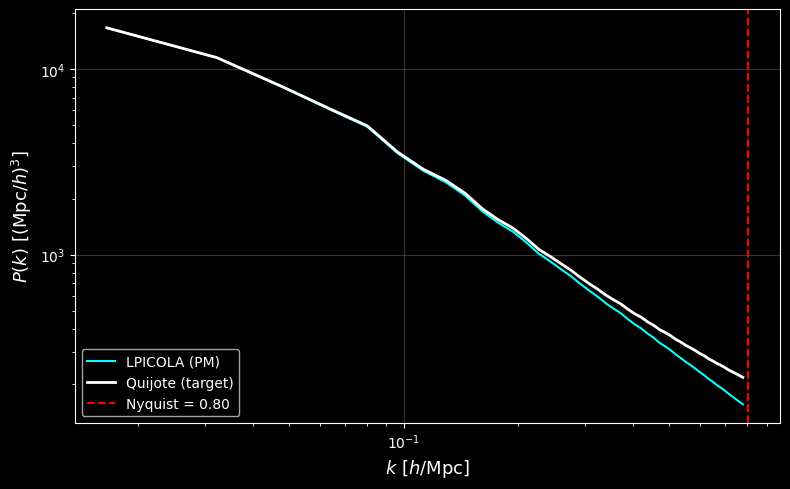

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_pm, Pk_pm, label="LPICOLA (PM)", color="cyan")
ax.plot(k_nb, Pk_nb, label="Quijote (target)", color="white", lw=2)
ax.axvline(kNyquist, color='r', ls='--', label='Nyquist = %.2f' % kNyquist)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax.legend(); ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "initial_power_spectra.pdf"), bbox_inches="tight")


# 2) Correlated case: $\phi_\mathbf{k} = (\gamma_k/k^2)\Delta_\mathbf{k}$


## 2-1) Polynomial (no bispectrum)

Dropping bispectrum and trispectrum terms (eq. 104 of the notes):
$$V\langle|\Delta'_\mathbf{k}|^2\rangle_\Delta = P(k) + \gamma_k^2P(k) + 2\gamma_k P(k) = P_\text{target}(k)$$
$$\Rightarrow\quad \gamma_k = -1 \pm \sqrt{P_\text{target}(k)/P(k)}$$

The "positive" root ($+$) is physically motivated when $P_\text{target}>P$ (need to add power),
and the "negative" root when $P_\text{target}<P$. Both are computed; we default to the positive
root but expose the choice.


In [12]:
def get_roots_gamma(k, Pk, Pk_target):
    '''
    Per-k quadratic: P*gamma^2 + 2P*gamma + (P - P_target) = 0
    Returns roots (n_k, 2) and coeffs (n_k, 3).
    '''
    a = Pk; b = 2*Pk; c = Pk - Pk_target
    coeffs = np.column_stack([a, b, c])
    roots  = np.array([np.roots(coeffs[i]) for i in range(len(k))])
    return roots, coeffs


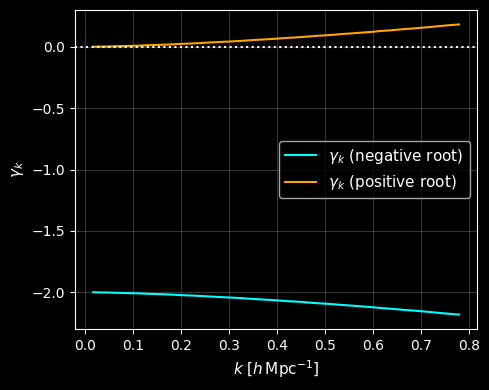

In [13]:
# Restrict to k <= kNyquist
inds = k_nb <= kN
k       = k_nb[inds]
Pk_pm_k = Pk_pm[inds]
Pk_nb_k = Pk_nb[inds]

roots, coeffs = get_roots_gamma(k, Pk_pm_k, Pk_nb_k)

# Positive root (use when P_target > P_PM mostly)
gamma_k = roots[:, 1].real

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k, roots[:, 0].real, label=r"$\gamma_k$ (negative root)", color="cyan")
ax.plot(k, roots[:, 1].real, label=r"$\gamma_k$ (positive root)", color="orange")
ax.axhline(0, ls="dotted", color="white")
ax.legend(fontsize=11)
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$\gamma_k$", fontsize=11)
ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gammak_roots.pdf"), bbox_inches="tight")


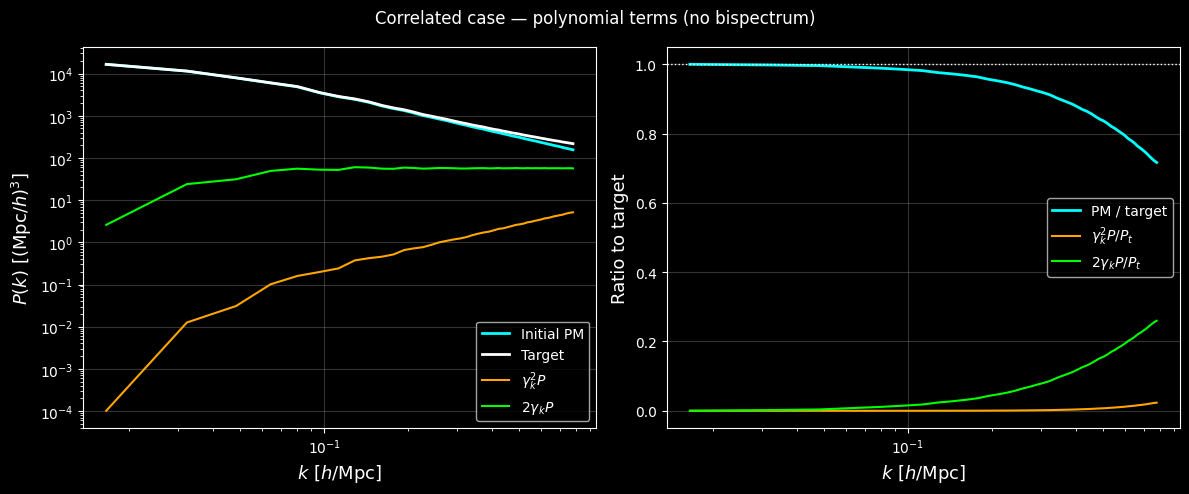

In [14]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k, Pk_pm_k,                         label="Initial PM",       color="cyan",   lw=2)
ax1.plot(k, Pk_nb_k,                          label="Target",           color="white",  lw=2)
ax1.plot(k, coeffs[:, 0]*gamma_k**2,          label=r"$\gamma_k^2 P$", color="orange", lw=1.5)
ax1.plot(k, coeffs[:, 1]*gamma_k,             label=r"$2\gamma_k P$",  color="lime",   lw=1.5)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

ax2.plot(k, Pk_pm_k/Pk_nb_k,                            label="PM / target",          color="cyan",   lw=2)
ax2.plot(k, coeffs[:, 0]*gamma_k**2/Pk_nb_k,            label=r"$\gamma_k^2P/P_t$",  color="orange", lw=1.5)
ax2.plot(k, coeffs[:, 1]*gamma_k/Pk_nb_k,               label=r"$2\gamma_k P/P_t$",  color="lime",   lw=1.5)
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)

plt.suptitle("Correlated case — polynomial terms (no bispectrum)")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "correlated_terms_noBk.pdf"), bbox_inches="tight")


## 2-2) Generate $\phi(\mathbf{x})$ and displace particles (polynomial $\gamma_k$)

$\phi_\mathbf{k} = (\gamma_k/k^2)\,\Delta_\mathbf{k}$, so we need the Fourier-space density
field $\Delta_\mathbf{k}$ from the PM snapshot. We then build $\nabla\phi$ via `ifft(ik\phi_k)`.

**No manual MAS correction is applied** to $\Delta_k$ — `CatalogFFTPower` handles that
internally for the $P(k)$ measurements, and applying it again here on the density field before
building $\phi$ would double-compensate the window. See the equation audit in the intro.


In [15]:
def MAS_correction(x, MAS_index):
    '''
    MAS deconvolution factor: (x/sin(x))^MAS_index.
    For CIC (MAS_index=2) with x = pi*f where f = fftfreq in [-0.5, 0.5):
        x/sin(x) = 1/sinc(f)  (unnormalized sinc)
    i.e. multiplying delta_k by this factor divides by the CIC window, recovering
    the unwindowed field. Matches pypower's _get_compensation_window 'shotnoise=False'
    path (eq. 18, Jing 2005): sinc(0.5/pi * kc)^p where kc = k * cellsize.
    '''
    x = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    nonzero = x != 0.0
    out[nonzero] = (x[nonzero] / np.sin(x[nonzero])) ** MAS_index
    return out


def get_delta_fourier(delta_pm, grid, BoxSize, n_threads=1,
                       apply_mas_deconv=True, MAS_index=2):
    '''
    Forward pyfftw of the real-space CIC density field -> fftshift-d Fourier field.

    apply_mas_deconv (default True): divide delta_k by the CIC window function
    in Fourier space, recovering the unwindowed density field.

    Why this matters -- confirmed from pypower source (mesh.py):

      CatalogMesh.to_mesh() has `compensate=False` by default. Compensation
      (MAS deconvolution) is only applied when compensate=True is passed, via
      _compensate() which divides the Fourier mesh by the CIC window. CatalogFFTPower
      itself never calls to_mesh() -- it creates CatalogMesh objects and delegates to
      MeshFFTPower (its parent class), which is where to_mesh(compensate=True) is
      actually called (confirmed from CatalogFFTPower source: the only nthreads usage
      is for the direct pair-counting engine, not the FFT path). But any raw mesh object (from CatalogMesh.to_mesh()
      or from MASL.MA + pyfftw as done here) does NOT have the window removed unless
      you explicitly request it.

      The pypower-native equivalent would be:
          CatalogMesh(pos_pm, nmesh=grid, boxsize=BoxSize, resampler='cic',
                      interlacing=2, position_type='pos').to_mesh(compensate=True)
      but that returns a pmesh.pm.ComplexField (slab-distributed), not a numpy array,
      requiring extra pmesh boilerplate to extract. MASL.MA + pyfftw + manual
      MAS_correction is mathematically equivalent and gives a plain numpy array.

    Small subtlety: CatalogFFTPower/MeshFFTPower combines two interlaced (phase-shifted) CIC meshes
    before compensating. MASL.MA is plain CIC without interlacing. The compensation
    formula used here (sinc^p, eq. 18 Jing 2005 = pypower's shotnoise=False path)
    is technically designed for the interlaced case; for a plain CIC field without
    interlacing, eq. 19 would be more consistent. The difference is small at k << kNyq.

    Set apply_mas_deconv=False to reproduce the original "without MAS" path
    (cells 44/75 of DM_benchmark_nico_pypower_1_.ipynb).
    '''
    prec_in = "complex64"
    a_in  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    a_out = pyfftw.empty_aligned((grid, grid, grid), dtype='complex64')
    plan  = pyfftw.FFTW(a_in, a_out, axes=(0, 1, 2), flags=('FFTW_ESTIMATE',),
                         direction='FFTW_FORWARD', threads=n_threads)
    a_in[:] = delta_pm.astype(prec_in)
    delta_k_shift = np.fft.fftshift(plan(a_in, a_out), axes=(0, 1, 2))

    if apply_mas_deconv:
        # f in [-0.5, 0.5), x = pi*f; MAS_correction(x,2) = 1/sinc(f)^2 = 1/W_CIC
        freq = np.fft.fftshift(np.fft.fftfreq(grid))
        fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')
        MAS_factor = (MAS_correction(np.pi * fx, MAS_index) *
                      MAS_correction(np.pi * fy, MAS_index) *
                      MAS_correction(np.pi * fz, MAS_index))
        delta_k_shift = delta_k_shift * MAS_factor.astype('complex64')

    return delta_k_shift

In [ ]:
# Build delta_pm field (needed to construct phi_k = gamma_k/k^2 * delta_k)
import MAS_library as MASL

delta_pm = np.zeros((grid, grid, grid), dtype=np.float32)
MASL.MA(pos_pm, delta_pm, BoxSize, MAS, verbose=False)
delta_pm /= np.mean(delta_pm, dtype=np.float64)
delta_pm -= 1.0

n_threads = resources['cpu_count'] or 1
delta_k_shift = get_delta_fourier(delta_pm, grid, BoxSize, n_threads=n_threads)
print("delta_k_shift shape/dtype:", delta_k_shift.shape, delta_k_shift.dtype)


In [ ]:
# Displace particles with polynomial gamma_k (no bispectrum)
phi_k_poly, accel_poly, _ = get_phi_and_accel_corr(
    gamma_k, k, delta_k_shift, grid, BoxSize, n_threads=n_threads,
    zero_above_kmax=True, verbose=True)

cell = BoxSize / grid
length_grid = np.arange(0., BoxSize, cell)
pos_corr_poly = np.empty(pos_pm.shape, dtype="float32")
pos_corr_poly, *_ = displace_positions_interp(
    pos_pm.astype("float32"), pos_corr_poly,
    accel_poly[0].astype("float32"),
    accel_poly[1].astype("float32"),
    accel_poly[2].astype("float32"),
    length_grid, length_grid, length_grid, BoxSize, threshold=BoxSize/grid)


In [ ]:
mean_disp = np.mean(np.linalg.norm(pos_corr_poly - pos_pm.astype('float32'), axis=1))
print("Mean |disp| = %.4g Mpc/h  (cell = %.4g Mpc/h)" % (mean_disp, BoxSize/grid))

k_poly, Pk_poly = cached_measure_power('corr_poly', pos_corr_poly, BoxSize, grid, kedges, ells=ells)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes
ax1.plot(k_pm,    Pk_pm,    label="PM (initial)",  color="darkblue", ls="--")
ax1.plot(k_poly,  Pk_poly,  label="Corr. (poly)",  color="orange")
ax1.plot(k_nb,    Pk_nb,    label="Target",         color="white", lw=2)
ax1.axvline(kNyquist, color='r', ls='--')
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

ax2.plot(k_pm, Pk_pm/np.interp(k_pm, k_nb, Pk_nb),    label="PM / target",  color="darkblue", ls="--")
ax2.plot(k_poly, Pk_poly/np.interp(k_poly, k_nb, Pk_nb), label="Corr. (poly) / target", color="orange")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.axvline(kNyquist, color='r', ls='--')
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Pk_corr_poly.pdf"), bbox_inches="tight")


## 2-3) Bispectrum computation (PolyBin3D)

We use the same `kedges` as pypower so that BSpec's $k_1,k_2$ bin centers land on the
same grid as our $P(k)$ bins — the key to building `build_bispectrum_matrix` without
any interpolation between the two grids.


In [ ]:
start = time.time()
base = pb.PolyBin3D(
    [BoxSize, BoxSize, BoxSize],
    [grid, grid, grid],
    boxcenter=[0, 0, 0],
    pixel_window='cic',
    backend='fftw',
    nthreads=n_threads,
    sightline='global')
print("PolyBin3D base init: %.1f s" % (time.time()-start))
print("k_fund = %.4f,  mean dk = %.4f" % (kFund, np.mean(np.diff(k_pm))))

down_factor = 1   # increase to speed up bispectrum (at the cost of k-resolution)
k_down = kedges[::down_factor]

bspec = pb.BSpec(base, k_down, lmax=0)
ks = bspec.get_ks()
k1_vals = np.unique(ks[0, :])
print("BSpec: %d valid triplets, %d unique k1 values" % (ks.shape[1], len(k1_vals)))


In [ ]:
recompbisp = False
bk_path = os.path.join("precomps", "bk_pm_bins%i_down%i.npy" % (num_bins, down_factor))
ks_path = os.path.join("precomps", "bk_bins_bins%i_down%i.npy" % (num_bins, down_factor))

if os.path.exists(bk_path) and not recompbisp:
    print("Loading bispectrum from cache")
    bk_uncorr = np.load(bk_path)
    ks        = np.load(ks_path)
else:
    start = time.time()
    result_bk = bspec.Bk_ideal(delta_pm, discreteness_correction=False)
    bk_uncorr = result_bk["b0"]
    ks        = bspec.get_ks()
    np.save(bk_path, bk_uncorr)
    np.save(ks_path, ks)
    print("Bispectrum computed in %.1f s" % (time.time()-start))

print("bk shape:", bk_uncorr.shape, "  ks shape:", ks.shape)
k1_vals = np.unique(ks[0, :])


## 2-4) Bispectrum term contribution

Using $\gamma_k$ from the polynomial (section 2-1) as a plug-in to visualize the
bispectrum term's magnitude — **not** yet solving for $\gamma$ from the full system.

The corrected sum-to-integral factor $1/(4\pi^3)$ (i.e. $2/(2\pi)^3$, from the
June 22 fix to cell 64 of the original) is used here. Note this replaces the
`bispectrum_term` in cell 81 of the original which still used the wrong $2/V$.


In [ ]:
def compute_bispectrum_term(gamma_vec, k_vec, ks, bk_monopole):
    '''
    Evaluate B.Term(k) = (k/(2pi^2)) int_0^{q_max} q gamma_q [int y B(k,q,k3) dy] dq
    at the k1 values available in ks, using gamma_vec on k_vec.

    Normalization: 1/(4*pi**3) -- corrected from the original cell 81 which used
    2/BoxSize^3 (old, wrong, pre-June-22 form). No BoxSize dependence here.
    '''
    interp_gamma = interp1d(k_vec, gamma_vec, kind="linear",
                             bounds_error=False, fill_value=(0., gamma_vec[-1]))

    k1_unique = np.unique(ks[0, :])
    B_term    = np.zeros(len(k1_unique))

    for i1, k1 in enumerate(k1_unique):
        sel     = np.where(ks[0, :] == k1)[0]
        k2_all  = ks[1, sel]; k3_all = ks[2, sel]; bk1 = bk_monopole[sel]
        k2_vals = np.unique(k2_all)

        B_integrand = np.zeros(len(k2_vals))
        for i2, k2 in enumerate(k2_vals):
            mask   = (k2_all == k2)
            k3_sub = k3_all[mask]; bk_sub = bk1[mask]
            y_arr  = (k1**2 + k2**2 - k3_sub**2) / (2*k1*k2)
            order  = np.argsort(y_arr)
            J = _trapz(y_arr[order]*bk_sub[order], y_arr[order])
            J *= 2*np.pi * k1/k2 * interp_gamma(k2)
            B_integrand[i2] = k2**2 * J

        B_term[i1] = _trapz(B_integrand, k2_vals)

    B_term *= 1. / (4 * np.pi**3)   # correct normalization (no BoxSize dependence)
    return k1_unique, B_term


In [ ]:
start = time.time()
k1v, B_term_poly = compute_bispectrum_term(gamma_k, k, ks, bk_uncorr)
print("Bispectrum term computed in %.2f s" % (time.time()-start))

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k,   Pk_pm_k,              label="Initial PM",          color="cyan",     ls="dotted", lw=1.5)
ax1.plot(k,   Pk_nb_k,              label="Target",              color="white",    lw=2)
ax1.plot(k,   coeffs[:,0]*gamma_k**2, label=r"$\gamma_k^2P$",    color="orange",   lw=1.5)
ax1.plot(k,   coeffs[:,1]*gamma_k,    label=r"$2\gamma_k P$",    color="lime",     lw=1.5)
ax1.plot(k1v, np.abs(B_term_poly),  label=r"|B term| ($\propto\gamma$)", color="magenta", ls="--", lw=2)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=12)
ax1.legend(fontsize=9, ncols=2); ax1.grid(color="grey", alpha=0.4)

Pk_nb_i = np.interp(k1v, k, Pk_nb_k)
ax2.plot(k,   Pk_pm_k/Pk_nb_k,              color="cyan",   ls="dotted", lw=1.5, label="PM/target")
ax2.plot(k,   coeffs[:,0]*gamma_k**2/Pk_nb_k, color="orange", lw=1.5, label=r"$\gamma^2P/P_t$")
ax2.plot(k,   coeffs[:,1]*gamma_k/Pk_nb_k,    color="lime",   lw=1.5, label=r"$2\gamma P/P_t$")
ax2.plot(k1v, np.abs(B_term_poly)/Pk_nb_i,  color="magenta", ls="--", lw=2, label="|B term|/target")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax2.set_ylabel("Ratio to target", fontsize=12)
ax2.legend(fontsize=9, ncols=2); ax2.grid(color="grey", alpha=0.4)

plt.suptitle("Bispectrum term contribution (using polynomial $\\gamma_k$)")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Bk_term_contribution.pdf"), bbox_inches="tight")


## 2-5) Linear system with bispectrum

Dropping the $\gamma_k^2$ term (linear system in $\gamma$):
$$P_\text{target} - P = 2P\,\gamma + \text{B.Term}(\gamma)
  = \bigl(2\,\mathrm{diag}(P) + M\bigr)\,\gamma$$

$M_{ij} = \frac{k_i\,k_j}{2\pi^2}I_\text{inner}(k_i,k_j)\,\Delta k_j$ is built by
`build_bispectrum_matrix` using the same `kedges` as pypower, so $k_1,k_2$ bin centers
from BSpec map exactly onto the $k$-grid — no interpolation needed between the two grids,
zero entries where no valid triangle exists.


In [ ]:
def build_bispectrum_matrix(k, ks, bk):
    '''
    Build M s.t. B.Term(k_i) = sum_j M[i,j] * gamma[j].

    I_inner[i,j] = integral_{-1}^{1} y * B(k_i, k_j, k3(y)) dy
    M[i,j] = k_i * k_j / (2*pi^2) * I_inner[i,j] * dk_j

    Key: run BSpec with the SAME kedges as pypower so k-values align exactly
    on the common k-grid. Entries are zero where no valid BSpec triangle exists.
    '''
    n_k = len(k)

    def k_to_idx(k_val):
        return int(np.argmin(np.abs(k - k_val)))

    I_inner = np.zeros((n_k, n_k))
    for k1 in np.unique(ks[0, :]):
        i    = k_to_idx(k1)
        sel  = np.where(ks[0, :] == k1)[0]
        k2_all = ks[1, sel]; k3_all = ks[2, sel]; bk_all = bk[sel]
        for k2 in np.unique(k2_all):
            j      = k_to_idx(k2)
            mask   = (k2_all == k2)
            k3_sub = k3_all[mask]; bk_sub = bk_all[mask]
            y_sub  = (k1**2 + k2**2 - k3_sub**2) / (2*k1*k2)
            order  = np.argsort(y_sub)
            I_inner[i, j] = _trapz(y_sub[order]*bk_sub[order], y_sub[order])

    dk = np.empty(n_k)
    dk[1:-1] = (k[2:] - k[:-2]) / 2
    dk[0]    = (k[1] - k[0]) / 2
    dk[-1]   = (k[-1] - k[-2]) / 2

    M = (1/(2*np.pi**2)) * k[:, None] * k[None, :] * I_inner * dk[None, :]
    return M


In [ ]:
start = time.time()
M = build_bispectrum_matrix(k, ks, bk_uncorr)
print("Bispectrum matrix built in %.2f s" % (time.time()-start))
print("M shape:", M.shape, "  nonzero entries:", np.count_nonzero(M))

A        = 2*np.diag(Pk_pm_k) + M
gamma_sol = np.linalg.solve(A, Pk_nb_k - Pk_pm_k)
B_term_sol = M @ gamma_sol

P_reconstructed = Pk_pm_k + 2*gamma_sol*Pk_pm_k + B_term_sol

print("Linear-system reconstruction check, max relative error:",
      np.max(np.abs(P_reconstructed - Pk_nb_k)/Pk_nb_k))


In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k, Pk_pm_k,         label="Initial PM",       color="cyan",    ls="dotted", lw=1.5)
ax1.plot(k, Pk_nb_k,         label="Target",            color="white",   lw=2)
ax1.plot(k, 2*gamma_sol*Pk_pm_k, label=r"$2\gamma P$", color="lime",    lw=1.5)
ax1.plot(k, np.abs(B_term_sol),  label=r"|B term| ($\gamma$ sol)", color="magenta", ls="--", lw=2)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=12)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

ax2.plot(k, Pk_pm_k/Pk_nb_k,             color="cyan",    ls="dotted", lw=1.5, label="PM/target")
ax2.plot(k, 2*gamma_sol*Pk_pm_k/Pk_nb_k, color="lime",    lw=1.5, label=r"$2\gamma P/P_t$")
ax2.plot(k, np.abs(B_term_sol)/Pk_nb_k,  color="magenta", ls="--", lw=2, label="|B term|/target")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax2.set_ylabel("Ratio to target", fontsize=12)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)

plt.suptitle(r"Bispectrum linear system — term contributions ($\gamma_\mathrm{sol}$)")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Bk_linear_terms.pdf"), bbox_inches="tight")


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k, gamma_k,    label=r"$\gamma_k$ (polynomial)", color="orange", ls="--")
ax.plot(k, gamma_sol,  label=r"$\gamma_k$ (linear + Bk)", color="cyan")
ax.axhline(0, color="white", lw=1, ls=":")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$\gamma_k$", fontsize=11)
ax.legend(fontsize=11); ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gammak_comparison.pdf"), bbox_inches="tight")


## 2-6) Displace particles with bispectrum-corrected $\gamma_k$

Same `get_phi_and_accel_corr` as section 2-2, now with `gamma_sol` in place of `gamma_k`.
The `delta_k_shift` is reused (not recomputed) since the PM density field hasn't changed.


In [ ]:
phi_k_lin, accel_lin, _ = get_phi_and_accel_corr(
    gamma_sol, k, delta_k_shift, grid, BoxSize, n_threads=n_threads,
    zero_above_kmax=True, verbose=True)

pos_corr_lin = np.empty(pos_pm.shape, dtype="float32")
pos_corr_lin, *_ = displace_positions_interp(
    pos_pm.astype("float32"), pos_corr_lin,
    accel_lin[0].astype("float32"),
    accel_lin[1].astype("float32"),
    accel_lin[2].astype("float32"),
    length_grid, length_grid, length_grid, BoxSize, threshold=BoxSize/grid)

mean_disp_lin = np.mean(np.linalg.norm(pos_corr_lin - pos_pm.astype('float32'), axis=1))
print("Mean |disp| = %.4g Mpc/h  (cell = %.4g Mpc/h)" % (mean_disp_lin, BoxSize/grid))


In [ ]:
k_lin,   Pk_lin   = cached_measure_power('corr_lin',  pos_corr_lin,  BoxSize, grid, kedges, ells=ells)
k_linr,  Pk_linr  = cached_measure_power('corr_linr', pos_corr_lin,  BoxSize, grid, kedges, ells=ells, remove_shotnoise=False)
k_polyr, Pk_polyr = cached_measure_power('corr_polyr',pos_corr_poly, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False)


In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k_pm,  Pk_pm,  label="PM (initial)",         color="darkblue", ls="--")
ax1.plot(k_poly,Pk_poly,label=r"Corr. (poly $\gamma$)",color="orange")
ax1.plot(k_lin, Pk_lin, label=r"Corr. (linear+Bk $\gamma$)", color="lime")
ax1.plot(k_nb,  Pk_nb,  label="Target",                color="white", lw=2)
ax1.axvline(kNyquist, color='r', ls='--', label='Nyquist')
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

for kk, Pk, lbl, col in [
    (k_pm,   Pk_pm,   "PM / target",       "darkblue"),
    (k_poly, Pk_poly, r"poly $\gamma$ / target", "orange"),
    (k_lin,  Pk_lin,  r"linear+Bk $\gamma$ / target", "lime"),
]:
    ax2.plot(kk, Pk/np.interp(kk, k_nb, Pk_nb), label=lbl, color=col,
              ls="--" if col=="darkblue" else "-")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.axvline(kNyquist, color='r', ls='--')
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Pk_corr_all.pdf"), bbox_inches="tight")


## 2-7) Cross-correlation coefficient $r(k)$

For the correlated case, improvements in $r(k)$ are the primary diagnostic — the whole
point of $\phi\propto\Delta$ is that the correction is coherent with the density field.

`remove_shotnoise=False` for both auto-spectra entering the denominator (same reason as the
Q-case notebook: pypower never subtracts shot noise from cross-spectra, so pairing a
shot-noise-subtracted auto with the raw cross term can give $r(k)>1$).


In [ ]:
def measure_crosscorr(pos_corr, pos_ref, k_ref_raw, Pk_ref_raw, BoxSize, grid, kedges, label=""):
    result_X = CatalogFFTPower(data_positions1=pos_ref, data_positions2=pos_corr,
                                boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,
                                position_type='pos', dtype='f4')
    k_X, Pk_X = result_X.poles(ell=ells[0], return_k=True, complex=False)
    mask = ~np.isnan(k_X) & ~np.isnan(Pk_X)
    k_X, Pk_X = k_X[mask], Pk_X[mask]

    k_auto, Pk_auto = measure_power_pypower(pos_corr, BoxSize, grid, kedges,
                                             ells=ells, remove_shotnoise=False)
    Pk_ref_i  = np.interp(k_X, k_ref_raw, Pk_ref_raw)
    Pk_auto_i = np.interp(k_X, k_auto, Pk_auto)
    r = Pk_X / np.sqrt(Pk_ref_i * Pk_auto_i)
    return k_X, r


In [ ]:
k_rX_pm,   r_pm   = measure_crosscorr(pos_pm,       pos_nb, k_nb_raw, Pk_nb_raw, BoxSize, grid, kedges)
k_rX_poly, r_poly = measure_crosscorr(pos_corr_poly, pos_nb, k_nb_raw, Pk_nb_raw, BoxSize, grid, kedges)
k_rX_lin,  r_lin  = measure_crosscorr(pos_corr_lin,  pos_nb, k_nb_raw, Pk_nb_raw, BoxSize, grid, kedges)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_rX_pm,   r_pm,   '--', color="darkblue", lw=2, label="PM (initial)")
ax.plot(k_rX_poly, r_poly, '-',  color="orange",   lw=2, label=r"Corr. (poly $\gamma$)")
ax.plot(k_rX_lin,  r_lin,  '-',  color="lime",     lw=2, label=r"Corr. (linear+Bk $\gamma$)")
ax.axhline(1.0, color="white", lw=1, ls=":")
ax.axvline(kNyquist, color='r', ls='--')
ax.set_xscale("log")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
ax.set_ylabel(r"$r(k) \equiv P_\times / \sqrt{P\,P^\mathrm{ref}}$", fontsize=12)
ax.legend(fontsize=10); ax.grid(color="gray", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_corr_all.pdf"), bbox_inches="tight")



# Misc) Root-finding with full system

The full system including $\gamma_k^2$ is nonlinear and cannot be solved per-$k$
independently since the bispectrum term couples all $k$-bins:
$$P(k) + \gamma_k^2P(k) + 2\gamma_kP(k) + \text{B.Term}(k;\gamma) = P_\text{target}(k)$$
We use `scipy.optimize.root` (Krylov method) initialized from `gamma_sol`.

**Two bugs fixed from the original (see intro):**
1. `bispectrum_term` in cell 81 of the original used `2/BoxSize³` (old normalization);
   `correlated_full_system` below uses `1/(4π³)` (corrected).
2. Cell 87 of the original displaced with `weights1D = solution["x"]` missing the
   `/k²` division; `get_phi_and_accel_corr` takes $\gamma_k$ and divides by $k^2$
   internally, so this is no longer possible to get wrong.


In [ ]:
def correlated_full_system(gamma_vec, k_vec, Pk_target, Pk_pm, ks, bk_mono):
    '''
    Residual of P + gamma^2*P + 2*gamma*P + B.Term(gamma) - P_target = 0.
    Uses the corrected bispectrum normalization 1/(4*pi^3).
    '''
    _, B = compute_bispectrum_term(gamma_vec, k_vec, ks, bk_mono)
    B_interp = np.interp(k_vec, np.unique(ks[0, :]), B)
    return Pk_pm - Pk_target + gamma_vec**2*Pk_pm + 2*gamma_vec*Pk_pm + B_interp


In [ ]:
# Krylov root-finder; init from linear solution, short run for demonstration
solution = scipy.optimize.root(
    correlated_full_system, x0=gamma_sol,
    args=(k, Pk_nb_k, Pk_pm_k, ks, bk_uncorr),
    method="krylov",
    options={"maxiter": 10, "fatol": 1e-3})

print("Converged:", solution.success, " message:", solution.message)
gamma_krylov = solution["x"]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k, gamma_k,      label=r"$\gamma_k$ (polynomial)",  color="orange", ls="--")
ax.plot(k, gamma_sol,    label=r"$\gamma_k$ (linear+Bk)",   color="cyan")
ax.plot(k, gamma_krylov, label=r"$\gamma_k$ (Krylov)",      color="magenta", ls=":")
ax.axhline(0, color="white", lw=1, ls=":")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$\gamma_k$", fontsize=11)
ax.legend(fontsize=10); ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gammak_all_methods.pdf"), bbox_inches="tight")


In [ ]:
# Displace with Krylov gamma -- note the /k^2 is inside get_phi_and_accel_corr
phi_k_kry, accel_kry, _ = get_phi_and_accel_corr(
    gamma_krylov, k, delta_k_shift, grid, BoxSize, n_threads=n_threads,
    zero_above_kmax=True, verbose=True)

pos_corr_kry = np.empty(pos_pm.shape, dtype="float32")
pos_corr_kry, *_ = displace_positions_interp(
    pos_pm.astype("float32"), pos_corr_kry,
    accel_kry[0].astype("float32"),
    accel_kry[1].astype("float32"),
    accel_kry[2].astype("float32"),
    length_grid, length_grid, length_grid, BoxSize, threshold=BoxSize/grid)

k_kry, Pk_kry = cached_measure_power('corr_krylov', pos_corr_kry, BoxSize, grid, kedges, ells=ells, recompute=True)


# Appendix: synthetic mock validation


Self-contained sanity check of the core pipeline functions on a lognormal mock catalog.
No pypower, readgadget, or real snapshots needed. Re-uses `get_roots_gamma`,
`build_bispectrum_matrix`, `get_phi_and_accel_corr`, `displace_positions_interp`.


In [ ]:
def cic_density_mock(positions, BoxSize, grid):
    N = positions.shape[0]; cell = BoxSize/grid
    pos_cell = positions/cell; i0 = np.floor(pos_cell).astype(int)
    d = pos_cell - i0; rho = np.zeros((grid,grid,grid))
    for dx in (0,1):
        for dy in (0,1):
            for dz in (0,1):
                w = (d[:,0] if dx else 1-d[:,0])*(d[:,1] if dy else 1-d[:,1])*(d[:,2] if dz else 1-d[:,2])
                np.add.at(rho, ((i0[:,0]+dx)%grid,(i0[:,1]+dy)%grid,(i0[:,2]+dz)%grid), w)
    return rho/N*grid**3 - 1.0

def measure_pk_mock(positions, BoxSize, grid, kbins, subtract_shotnoise=True):
    delta = cic_density_mock(positions, BoxSize, grid)
    V = BoxSize**3; dV = (BoxSize/grid)**3
    delta_k = np.fft.fftn(delta)*dV/V; pf = (V*np.abs(delta_k)**2).ravel()
    kf = 2*np.pi/BoxSize; k1d = np.fft.fftfreq(grid,d=1./grid)*kf
    KX,KY,KZ = np.meshgrid(k1d,k1d,k1d,indexing='ij'); kmag = np.sqrt(KX**2+KY**2+KZ**2).ravel()
    idx = np.digitize(kmag, kbins)
    k_out,P_out = [],[]
    for b in range(1,len(kbins)):
        sel = idx==b
        if sel.sum()==0: continue
        k_out.append(kmag[sel].mean()); P_out.append(pf[sel].mean())
    k_out,P_out = np.array(k_out),np.array(P_out)
    if subtract_shotnoise: P_out -= V/positions.shape[0]
    return k_out, P_out

def lognormal_mock(Pk_func, BoxSize, grid, nbar, seed=None):
    rng = np.random.default_rng(seed); w = rng.standard_normal((grid,grid,grid))
    kf = 2*np.pi/BoxSize; k1d = np.fft.fftfreq(grid,d=1./grid)*kf
    KX,KY,KZ = np.meshgrid(k1d,k1d,k1d,indexing='ij'); kmag = np.sqrt(KX**2+KY**2+KZ**2)
    dV = (BoxSize/grid)**3; Pk = Pk_func(kmag.ravel()).reshape(kmag.shape); Pk[kmag==0]=0.
    delta_g = np.fft.ifftn(np.sqrt(np.clip(Pk,0,None)/dV)*np.fft.fftn(w)).real
    sigma2 = delta_g.var(); lam = np.clip(nbar*(np.exp(delta_g-sigma2/2.)-1.+1.)*dV,0,None)
    counts = rng.poisson(lam); idx = np.argwhere(counts>0)
    base = np.repeat(idx, counts[counts>0], axis=0).astype(float)
    return ((base + rng.uniform(0,1,base.shape))*(BoxSize/grid)) % BoxSize


In [ ]:
BoxSize_m, grid_m, nbar_m = 200.0, 32, 0.02
kbins_m = np.linspace(0.05, 0.9, 14)

def P_PM_m(k):  return 1.2e4*(k/0.15)**-1.6/(1+(k/0.15)**2)
def P_tgt_m(k): return 2.0e4*(k/0.18)**-1.5/(1+(k/0.18)**2)

pos_pm_m = lognormal_mock(P_PM_m, BoxSize_m, grid_m, nbar_m, seed=42)
pos_nb_m = lognormal_mock(P_tgt_m, BoxSize_m, grid_m, nbar_m, seed=42)  # same seed -> correlated

k_pm_m, Pk_pm_m = measure_pk_mock(pos_pm_m, BoxSize_m, grid_m, kbins_m)
k_nb_m, Pk_nb_m = measure_pk_mock(pos_nb_m, BoxSize_m, grid_m, kbins_m)

roots_m, coeffs_m = get_roots_gamma(k_pm_m, Pk_pm_m, Pk_nb_m)
gamma_k_m = roots_m[:, 1].real
print("gamma_k (mock):", gamma_k_m[:5])

# Reconstruct expected P(k) from polynomial
P_check = Pk_pm_m*(1 + gamma_k_m)**2
print("Max relative error in polynomial reconstruction:",
      np.max(np.abs(P_check - Pk_nb_m)/Pk_nb_m))

# Displace with polynomial gamma
delta_pm_m = cic_density_mock(pos_pm_m, BoxSize_m, grid_m)
delta_k_m  = get_delta_fourier(delta_pm_m, grid_m, BoxSize_m, n_threads=2)
phi_k_m, accel_m, n_z = get_phi_and_accel_corr(
    gamma_k_m, k_pm_m, delta_k_m, grid_m, BoxSize_m, n_threads=2,
    zero_above_kmax=True, verbose=True)

cell_m = BoxSize_m/grid_m; lg_m = np.arange(0., BoxSize_m, cell_m)
pos_corr_m = np.empty(pos_pm_m.shape, dtype="float32")
pos_corr_m, *_ = displace_positions_interp(
    pos_pm_m.astype("float32"), pos_corr_m,
    accel_m[0].astype("float32"), accel_m[1].astype("float32"), accel_m[2].astype("float32"),
    lg_m, lg_m, lg_m, BoxSize_m, threshold=BoxSize_m/grid_m)

k_corr_m, Pk_corr_m = measure_pk_mock(pos_corr_m, BoxSize_m, grid_m, kbins_m)
print("Mock validation done. positions_corrected dtype:", pos_corr_m.dtype)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_pm_m,   Pk_pm_m,   'o-', label="PM (initial)",  color="dodgerblue")
ax.plot(k_nb_m,   Pk_nb_m,   '-',  label="Target",        color="white", lw=2)
ax.plot(k_corr_m, Pk_corr_m, 's--',label="Corrected",     color="orange")
ax.set_xscale("log")
ax.set_xlabel(r"$k$"); ax.set_ylabel(r"$P(k)$")
ax.legend(fontsize=10); ax.grid(color="grey", alpha=0.4)
ax.set_title("Synthetic-mock validation: correlated case")
plt.tight_layout()
